# TP 3 - Nettoyage et Feature Engineering
## Mastère 2 - Data & Intelligence Artificielle


### Objectifs
1. Traiter les valeurs manquantes (stratégie médiane/mode)
2. Détecter et traiter les outliers (méthode IQR et capping)
3. Créer des features métier pertinentes
4. Encoder les variables catégorielles
5. Sauvegarder le dataset nettoyé

### Critères de réussite
- ✅ Aucune valeur manquante dans le dataset final
- ✅ Au moins 5 nouvelles features créées
- ✅ Toutes les variables catégorielles encodées
- ✅ Dataset sauvegardé en CSV

## 📦 Imports

In [1]:
# Import des librairies nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration d'affichage
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

print("✅ Imports réussis")

✅ Imports réussis


## 📊 Chargement des données

In [2]:
# Charger le dataset
df = pd.read_csv("loan_data.csv")

print("=" * 80)
print("DATASET INITIAL")
print("=" * 80)
print(f"Dimensions : {df.shape}")
print(df.head())

# Créer une copie pour le travail
df_clean = df.copy()

DATASET INITIAL
Dimensions : (614, 13)
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         R

In [3]:
# Supprimer la colonne Loan_ID si elle existe
if "Loan_ID" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Loan_ID"])

print("Colonnes restantes :")
print(df_clean.columns.tolist())

Colonnes restantes :
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


---
## 🔧 ÉTAPE 1 : Traitement des valeurs manquantes

### Stratégie
- **Variables numériques** : Imputer avec la **médiane**
- **Variables catégorielles** : Imputer avec le **mode**

### Questions à se poser
- Pourquoi la médiane plutôt que la moyenne ?
- Quelles colonnes ont des valeurs manquantes ?

In [4]:
print("\n" + "=" * 80)
print("ÉTAPE 1 : TRAITEMENT DES VALEURS MANQUANTES")
print("=" * 80)

# Définir les colonnes numériques et catégorielles
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude=[np.number]).columns.tolist()

print("Colonnes numériques :", numerical_cols)
print("Colonnes catégorielles :", categorical_cols)
print("\nValeurs manquantes avant imputation :")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0].sort_values(ascending=False))


ÉTAPE 1 : TRAITEMENT DES VALEURS MANQUANTES
Colonnes numériques : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Colonnes catégorielles : ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

Valeurs manquantes avant imputation :
Credit_History      50
Self_Employed       32
LoanAmount          22
Dependents          15
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64


### Imputation des variables numériques

In [5]:
# Imputer les valeurs manquantes numériques avec la médiane
for col in numerical_cols:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

print("✅ Imputation numérique terminée")
print(df_clean[numerical_cols].isnull().sum().sum(), "NaN restants dans les colonnes numériques")

✅ Imputation numérique terminée
0 NaN restants dans les colonnes numériques


### Imputation des variables catégorielles

In [6]:
# Imputer les valeurs manquantes catégorielles avec le mode
for col in categorical_cols:
    mode_value = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_value)

print("✅ Imputation catégorielle terminée")
print(df_clean[categorical_cols].isnull().sum().sum(), "NaN restants dans les colonnes catégorielles")

✅ Imputation catégorielle terminée
0 NaN restants dans les colonnes catégorielles


In [7]:
# Vérifier qu'il n'y a plus de NaN
total_missing = df_clean.isnull().sum().sum()
print(f"Nombre total de NaN après imputation : {total_missing}")

Nombre total de NaN après imputation : 0


---
## 🎯 ÉTAPE 2 : Détection et traitement des outliers

### Méthode IQR
- **Q1** : Premier quartile (25%)
- **Q3** : Troisième quartile (75%)
- **IQR** : Q3 - Q1
- **Outliers** : < Q1 - 1.5×IQR ou > Q3 + 1.5×IQR

### Notre approche : Capping
Plafonner aux percentiles 1% et 99%


ÉTAPE 2 : DÉTECTION ET TRAITEMENT DES OUTLIERS


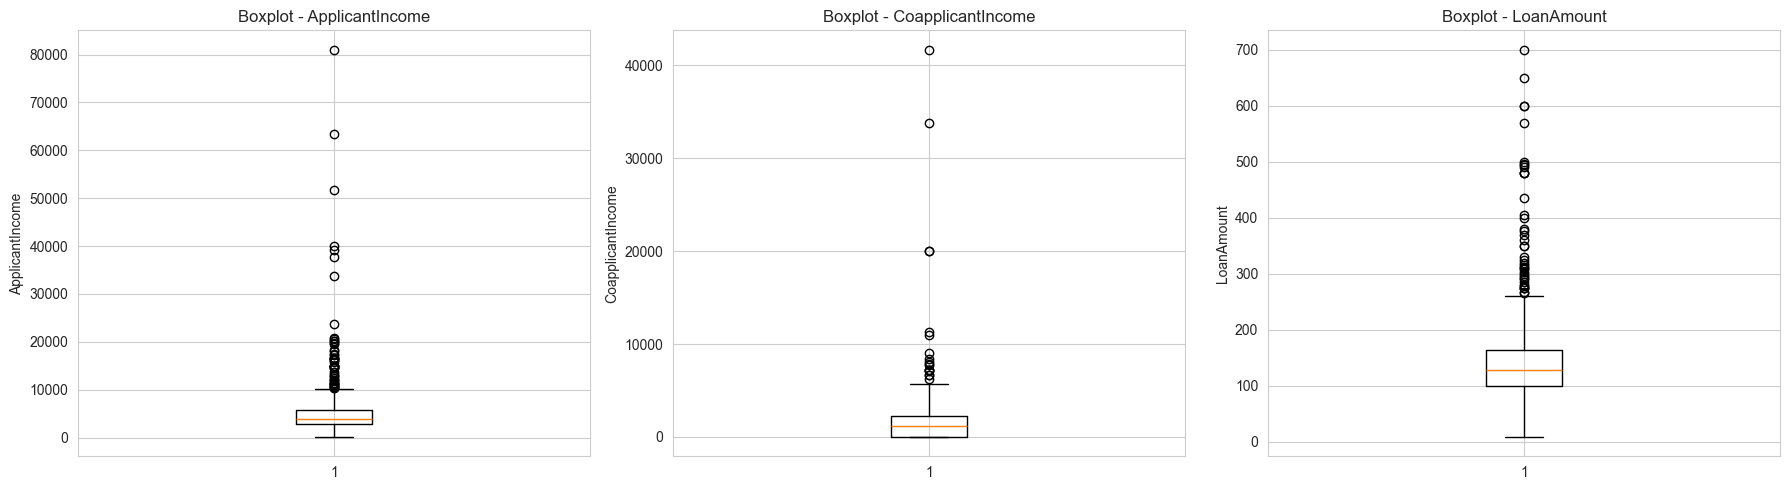

In [8]:
print("\n" + "=" * 80)
print("ÉTAPE 2 : DÉTECTION ET TRAITEMENT DES OUTLIERS")
print("=" * 80)

# Boxplots pour visualiser les outliers
cols_to_plot = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cols_to_plot):
    axes[i].boxplot(df_clean[col].dropna(), vert=True)
    axes[i].set_title(f"Boxplot - {col}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Fonction de capping

In [9]:
# Fonction de capping
def cap_outliers(df, column, lower_percentile=1, upper_percentile=99):
    """
    Plafonne les valeurs extrêmes en utilisant des percentiles.
    """
    lower_bound = np.percentile(df[column].dropna(), lower_percentile)
    upper_bound = np.percentile(df[column].dropna(), upper_percentile)
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

print("✅ Fonction cap_outliers créée")

✅ Fonction cap_outliers créée


In [10]:
# Appliquer le capping sur les revenus et LoanAmount
for col in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]:
    df_clean = cap_outliers(df_clean, col, lower_percentile=1, upper_percentile=99)

print("✅ Capping appliqué sur ApplicantIncome, CoapplicantIncome et LoanAmount")

✅ Capping appliqué sur ApplicantIncome, CoapplicantIncome et LoanAmount


---
## 🏗️ ÉTAPE 3 : Feature Engineering

### Features à créer
1. **TotalIncome** : Revenu total du ménage
2. **LoanAmountToIncome** : Ratio d'endettement
3. **EMI** : Mensualité estimée
4. **EMIToIncome** : Part du revenu pour remboursement
5. **Log_LoanAmount** : Transformation logarithmique
6. **Log_TotalIncome** : Transformation logarithmique
7. **Has_Coapplicant** : Indicateur binaire

In [11]:
print("\n" + "=" * 80)
print("ÉTAPE 3 : FEATURE ENGINEERING")
print("=" * 80)


ÉTAPE 3 : FEATURE ENGINEERING


In [12]:
# Créer TotalIncome
df_clean["TotalIncome"] = df_clean["ApplicantIncome"] + df_clean["CoapplicantIncome"]

print("✅ Feature TotalIncome créée")
print(df_clean[["ApplicantIncome", "CoapplicantIncome", "TotalIncome"]].head())

✅ Feature TotalIncome créée
   ApplicantIncome  CoapplicantIncome  TotalIncome
0           5849.0                0.0       5849.0
1           4583.0             1508.0       6091.0
2           3000.0                0.0       3000.0
3           2583.0             2358.0       4941.0
4           6000.0                0.0       6000.0


In [13]:
# Créer LoanAmountToIncome
df_clean["LoanAmountToIncome"] = np.where(
    df_clean["TotalIncome"] > 0,
    df_clean["LoanAmount"] / df_clean["TotalIncome"],
    0
)

print("✅ Feature LoanAmountToIncome créée")

✅ Feature LoanAmountToIncome créée


In [14]:
# Créer EMI (mensualité)
df_clean["EMI"] = np.where(
    df_clean["Loan_Amount_Term"] > 0,
    df_clean["LoanAmount"] / df_clean["Loan_Amount_Term"],
    0
)

print("✅ Feature EMI créée")

✅ Feature EMI créée


In [15]:
# Créer EMIToIncome
df_clean["EMIToIncome"] = np.where(
    df_clean["TotalIncome"] > 0,
    df_clean["EMI"] / df_clean["TotalIncome"],
    0
)

print("✅ Feature EMIToIncome créée")

✅ Feature EMIToIncome créée


In [16]:
# Créer Log_LoanAmount et Log_TotalIncome
df_clean["Log_LoanAmount"] = np.log(df_clean["LoanAmount"] + 1)
df_clean["Log_TotalIncome"] = np.log(df_clean["TotalIncome"] + 1)

print("✅ Features logarithmiques créées")

✅ Features logarithmiques créées


In [17]:
# Créer Has_Coapplicant
df_clean["Has_Coapplicant"] = (df_clean["CoapplicantIncome"] > 0).astype(int)

print("✅ Feature Has_Coapplicant créée")

✅ Feature Has_Coapplicant créée


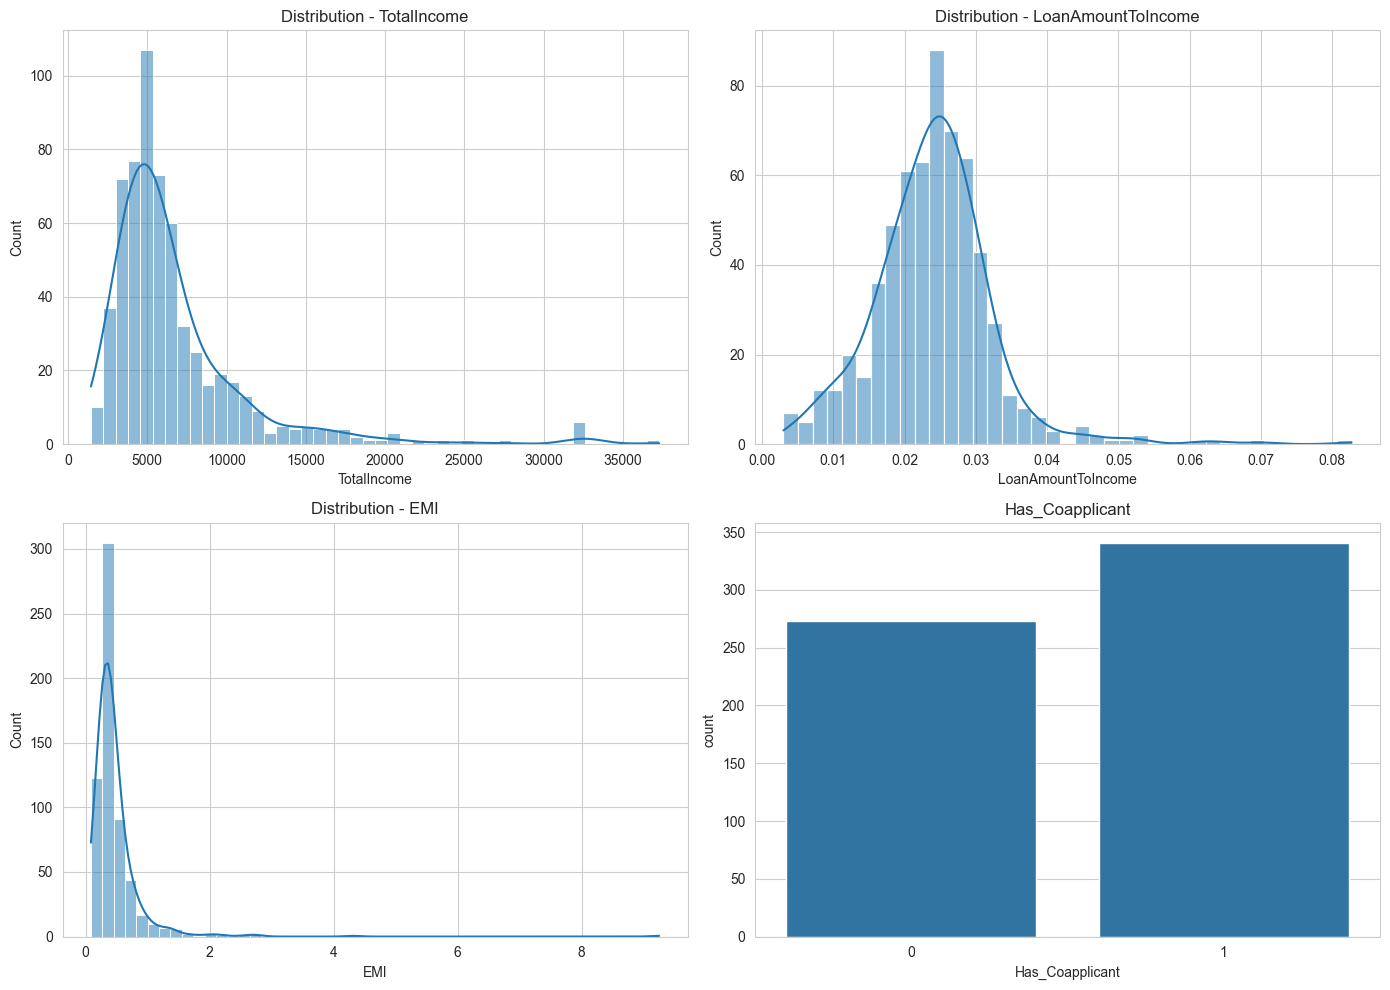

In [18]:
# Visualisations (bonus) des nouvelles features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df_clean["TotalIncome"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution - TotalIncome")

sns.histplot(df_clean["LoanAmountToIncome"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Distribution - LoanAmountToIncome")

sns.histplot(df_clean["EMI"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribution - EMI")

sns.countplot(x="Has_Coapplicant", data=df_clean, ax=axes[1, 1])
axes[1, 1].set_title("Has_Coapplicant")

plt.tight_layout()
plt.show()

---
## 🔤 ÉTAPE 4 : Encodage des variables catégorielles

### Deux méthodes
1. **Label Encoding** : Pour variables ordinales (avec ordre)
2. **One-Hot Encoding** : Pour variables nominales (sans ordre)

In [19]:
print("\n" + "=" * 80)
print("ÉTAPE 4 : ENCODAGE DES VARIABLES CATÉGORIELLES")
print("=" * 80)


ÉTAPE 4 : ENCODAGE DES VARIABLES CATÉGORIELLES


### Label Encoding

In [20]:
# Encoder Education (Graduate = 1, Not Graduate = 0)
df_clean["Education"] = df_clean["Education"].map({"Graduate": 1, "Not Graduate": 0})

print("✅ Education encodée")

✅ Education encodée


In [21]:
# Encoder Loan_Status (Y = 1, N = 0)
df_clean["Loan_Status"] = df_clean["Loan_Status"].map({"Y": 1, "N": 0})

print("✅ Loan_Status encodée")

✅ Loan_Status encodée


### One-Hot Encoding

In [22]:
# Encoder Property_Area avec One-Hot Encoding
df_clean = pd.get_dummies(df_clean, columns=["Property_Area"], drop_first=True, dtype=int)

print("✅ Property_Area encodée avec One-Hot Encoding")

✅ Property_Area encodée avec One-Hot Encoding


In [23]:
# Encoder Gender, Married, Self_Employed
binary_maps = {
    "Gender": {"Male": 1, "Female": 0},
    "Married": {"Yes": 1, "No": 0},
    "Self_Employed": {"Yes": 1, "No": 0},
}

for col, mapping in binary_maps.items():
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(mapping)

print("✅ Gender, Married et Self_Employed encodées")

✅ Gender, Married et Self_Employed encodées


In [24]:
# Traiter Dependents (convertir '3+' en 3)
df_clean["Dependents"] = df_clean["Dependents"].replace("3+", "3").astype(float)

print("✅ Dependents convertie en numérique")

✅ Dependents convertie en numérique


---
## ✅ ÉTAPE 5 : Vérifications finales

In [25]:
print("\n" + "=" * 80)
print("ÉTAPE 5 : VÉRIFICATIONS FINALES")
print("=" * 80)

# Vérifier qu'il n'y a plus de NaN
missing_final = df_clean.isnull().sum().sum()
print(f"Nombre total de NaN dans le dataset final : {missing_final}")

if missing_final == 0:
    print("✅ Aucune valeur manquante")
else:
    print("⚠️ Colonnes avec NaN restants :")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


ÉTAPE 5 : VÉRIFICATIONS FINALES
Nombre total de NaN dans le dataset final : 0
✅ Aucune valeur manquante


In [26]:
# Afficher les types de données
print(df_clean.dtypes.sort_index())

ApplicantIncome            float64
CoapplicantIncome          float64
Credit_History             float64
Dependents                 float64
EMI                        float64
EMIToIncome                float64
Education                    int64
Gender                       int64
Has_Coapplicant              int64
LoanAmount                 float64
LoanAmountToIncome         float64
Loan_Amount_Term           float64
Loan_Status                  int64
Log_LoanAmount             float64
Log_TotalIncome            float64
Married                      int64
Property_Area_Semiurban      int64
Property_Area_Urban          int64
Self_Employed                int64
TotalIncome                float64
dtype: object


In [27]:
# Afficher les dimensions finales et un aperçu
print(f"Dimensions finales : {df_clean.shape}")
print(df_clean.head())

Dimensions finales : (614, 20)
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0         0.0          1              0           5849.0   
1       1        1         1.0          1              0           4583.0   
2       1        1         0.0          1              1           3000.0   
3       1        1         0.0          0              0           2583.0   
4       1        0         0.0          1              0           6000.0   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Loan_Status  TotalIncome  LoanAmountToIncome       EMI  EMIToIncome  \
0          

---
## 💾 ÉTAPE 6 : Sauvegarde

In [28]:
print("\n" + "=" * 80)
print("ÉTAPE 6 : SAUVEGARDE DU DATASET NETTOYÉ")
print("=" * 80)

# Sauvegarder le dataset nettoyé
output_file = "loan_data_clean.csv"
df_clean.to_csv(output_file, index=False)

print(f"✅ Dataset sauvegardé : {output_file}")


ÉTAPE 6 : SAUVEGARDE DU DATASET NETTOYÉ
✅ Dataset sauvegardé : loan_data_clean.csv


---
## 📝 Questions de réflexion

1. **Pourquoi utiliser la médiane plutôt que la moyenne pour imputer les valeurs manquantes ?**

2. **Quelle est la différence entre Label Encoding et One-Hot Encoding ? Quand utiliser l'un ou l'autre ?**

3. **Pourquoi créer des features comme TotalIncome et EMI plutôt que laisser le modèle les découvrir ?**

4. **Qu'est-ce que le capping et pourquoi est-il préférable à la suppression des outliers ?**

**Notez vos réponses ci-dessous :**

**Vos réponses :**

1. La médiane est plus robuste aux valeurs extrêmes (outliers) que la moyenne. Dans ce dataset, certaines variables comme les revenus peuvent être très asymétriques, donc la médiane représente mieux la valeur "typique" et évite de biaiser l’imputation.

2. Le Label Encoding remplace chaque catégorie par un entier (ex: Oui=1, Non=0). Il est adapté aux variables binaires ou ordinales (où un ordre existe). Le One-Hot Encoding crée une colonne par modalité (0/1) et convient aux variables nominales sans ordre (ex: zone géographique), pour ne pas introduire de faux ordre.

3. Créer des features métier aide le modèle à capter des relations utiles plus directement (ex: revenu total, charge mensuelle, ratio dette/revenu). Cela peut améliorer les performances, accélérer l’apprentissage et rendre les résultats plus interprétables.

4. Le capping consiste à plafonner les valeurs extrêmes à des bornes (ici percentiles 1% et 99%). C’est souvent préférable à la suppression car on conserve toutes les observations (pas de perte d’information), tout en limitant l’impact excessif des outliers sur le modèle.

In [29]:
# Cellule libre : aperçu statistique du dataset final
df_clean.describe(include="all").T.head(15)

,count,mean,std,min,25%,50%,75%,max
Gender,614.0,0.817590,0.386497,0.000000,1.000000,1.000000,1.000000,1.000000
Married,614.0,0.653094,0.476373,0.000000,0.000000,1.000000,1.000000,1.000000
Dependents,614.0,0.744300,1.009623,0.000000,0.000000,0.000000,1.000000,3.000000
Education,614.0,0.781759,0.413389,0.000000,1.000000,1.000000,1.000000,1.000000
Self_Employed,614.0,0.133550,0.340446,0.000000,0.000000,0.000000,0.000000,1.000000
ApplicantIncome,614.0,5214.577964,4528.770082,1025.000000,2877.500000,3812.500000,5795.000000,32540.410000
CoapplicantIncome,614.0,1483.654967,1831.226927,0.000000,0.000000,1188.500000,2297.250000,8895.890000
LoanAmount,614.0,144.787687,78.513474,30.650000,100.250000,128.000000,164.750000,495.870000
Loan_Amount_Term,614.0,342.410423,64.428629,12.000000,360.000000,360.000000,360.000000,480.000000
Credit_History,614.0,0.855049,0.352339,0.000000,1.000000,1.000000,1.000000,1.000000


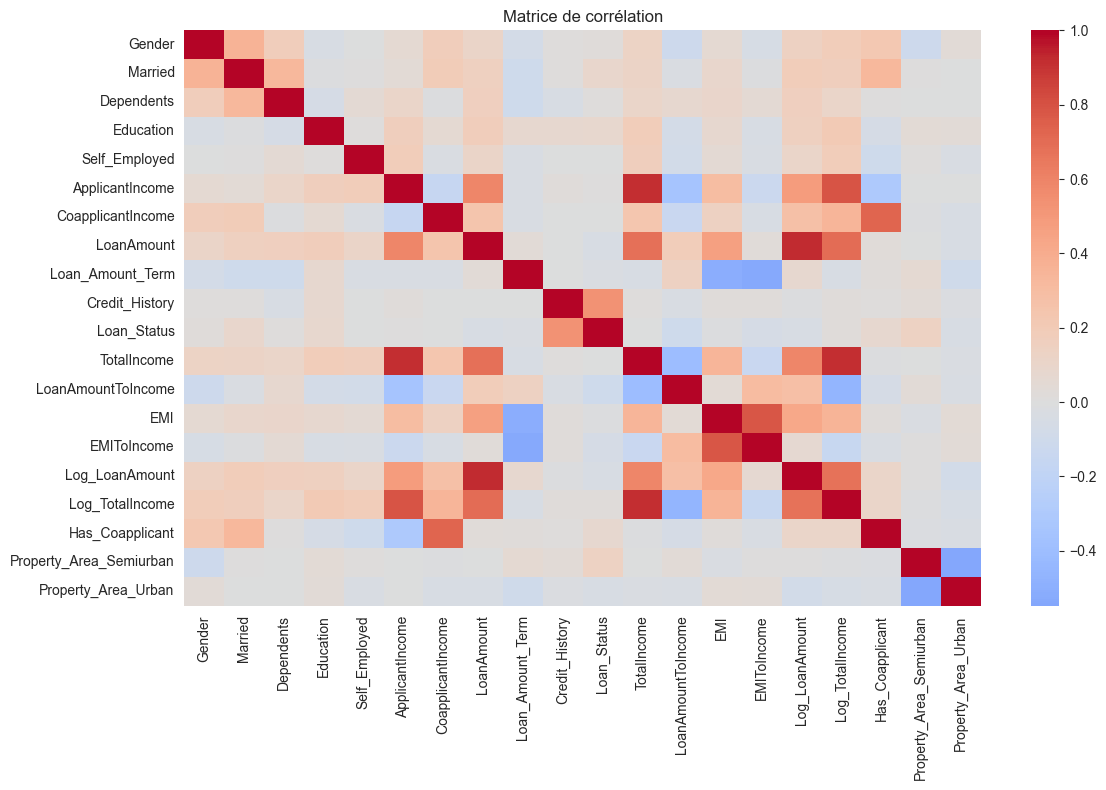

In [30]:
# Cellule libre : corrélation des variables numériques
numeric_df = df_clean.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()